#                                              Titanic Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load the tianic dataset

In [2]:
df = pd.read_csv('titanic.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

C:\Users\kravi\AppData\Local\Temp\ipykernel_8620\2359842934.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\kravi\AppData\Local\Temp\ipykernel_8620\2359842934.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [8]:
df.drop('Cabin', axis=1, inplace=True)

In [9]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

**Answer questions such as:**
1. Who survived more: males or females?
2. Did passenger class affect survival chances?
3. What was the survival rate by age group?

In [10]:
Survived_gender = df.groupby('Sex')['Survived'].mean()
Survived_gender

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [11]:
Survival_class = df.groupby('Pclass')['Survived'].mean()
Survival_class

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [12]:
df['AgeGroup'] = pd.cut(df['Age'],bins=[0,12,18,35,60,100],labels=['Child','Teen','Adult','Middle','Senior'])
age_survival = df.groupby('AgeGroup')['Survived'].mean()
age_survival


C:\Users\kravi\AppData\Local\Temp\ipykernel_8620\1801167773.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby('AgeGroup')['Survived'].mean()


AgeGroup
Child     0.579710
Teen      0.428571
Adult     0.353271
Middle    0.400000
Senior    0.227273
Name: Survived, dtype: float64

**Visualize using Seaborn / Matplotlib:**
1. Bar chart of survival by gender.
2. Bar chart of survival by class.
3. Histogram of passenger ages

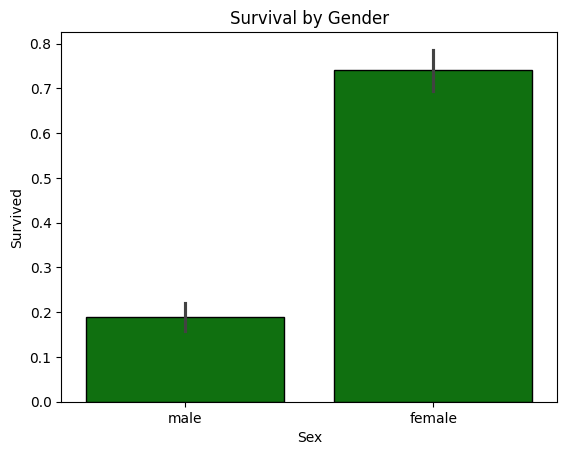

In [13]:
sns.barplot(x='Sex', y='Survived', data=df, color='green', edgecolor='black')
plt.title("Survival by Gender")
plt.show()

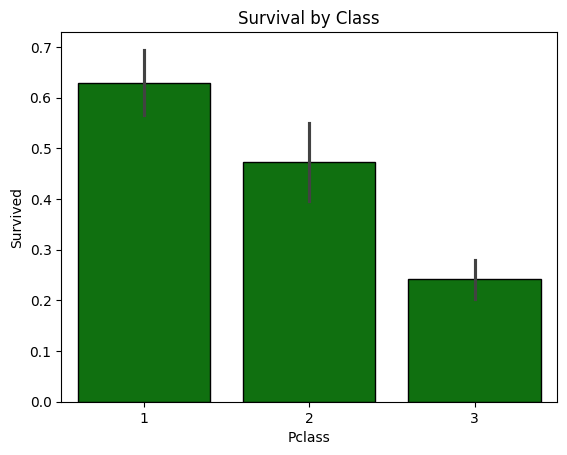

In [14]:
sns.barplot(x='Pclass', y='Survived', data=df, color='green', edgecolor='black')
plt.title("Survival by Class")
plt.show()

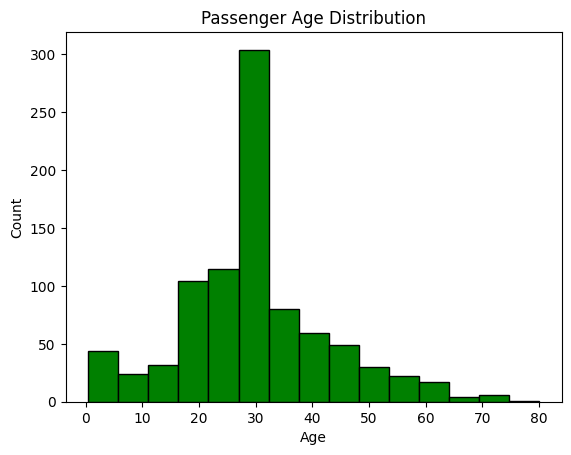

In [15]:
plt.hist(df['Age'], bins=15, color='green', edgecolor='black')
plt.title("Passenger Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [18]:
df.to_csv("clean_titanic", index=False)